In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# 1. 檔案讀寫 (File I/O)

def read_sequential_raw(filename, width=512, height=512):
    """
    讀取 Sequential (Planar) 格式的 Raw 檔
    格式：先存全部R -> 再存全部G -> 再存全部B 
    """
    if not os.path.exists(filename):
        print(f"Error: 找不到檔案 {filename}")
        return None

    # 使用 uint8 讀取 binary
    raw_data = np.fromfile(filename, dtype=np.uint8)
    
    # 檢查檔案大小是否正確
    expected_size = width * height * 3
    if raw_data.size != expected_size:
        print(f"Error: 檔案大小不符 (Expected {expected_size}, got {raw_data.size})")
        return None

    # Reshape 成 (3, H, W) 代表 (Channel, Height, Width)
    img_planar = raw_data.reshape((3, height, width))
    
    # 轉置成 Python 習慣的 (H, W, 3) 方便處理
    img = img_planar.transpose((1, 2, 0))
    return img

def save_sequential_raw(img, filename):
    """
    將影像存回 Sequential 格式的 Raw 檔
    """
    # 1. 確保數值在 0-255 之間 (Clipping) 以避免 Overflow 
    img_clipped = np.clip(img, 0, 255).astype(np.uint8)
    
    # 2. 轉回 Planar 格式 (3, H, W)
    img_planar = img_clipped.transpose((2, 0, 1))
    
    # 3. 寫入檔案 
    img_planar.tofile(filename)
    print(f"File saved to: {filename}")

In [3]:
# 2. 色彩空間轉換

def rgb_to_hsi(img):
    """
    RGB 轉 HSI，實作講義 Slide 3 公式
    """
    # 轉為浮點數進行高精度運算，並歸一化到 0-255 範圍計算 I
    img = img.astype(np.float64)
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    
    # --- 計算 Intensity (I) ---
    # I = (R + G + B) / 3 [cite: 30]
    I = (R + G + B) / 3.0
    
    # --- 計算 Saturation (S) ---
    # S = 1 - 3/(R+G+B) * min(R,G,B) [cite: 30]
    sum_rgb = R + G + B
    min_rgb = np.minimum(np.minimum(R, G), B)
    
    # 避免分母為 0
    with np.errstate(divide='ignore', invalid='ignore'):
        S = 1.0 - (3.0 * min_rgb / (sum_rgb + 1e-6))
    S[sum_rgb == 0] = 0 # 若 RGB 全黑，S 定義為 0
    
    # --- 計算 Hue (H) ---
    # theta = cos^-1
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B) * (G - B))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        theta = np.arccos(num / (den + 1e-6))
    
    # 將弧度轉為角度
    theta = np.degrees(theta)
    
    # H = theta if B <= G else 360 - theta
    H = np.copy(theta)
    H[B > G] = 360.0 - H[B > G]
    
    # 修正 NaN (處理純灰階情況)
    H[np.isnan(H)] = 0.0
    
    return H, S, I

def hsi_to_rgb(H, S, I):
    """
    HSI 轉 RGB，實作講義 Slide 3 分段公式 
    """
    H = np.copy(H)
    S = np.copy(S)
    I = np.copy(I)
    
    R = np.zeros_like(I)
    G = np.zeros_like(I)
    B = np.zeros_like(I)
    
    # 轉換角度為弧度供三角函數使用
    def deg2rad(d):
        return d * (np.pi / 180.0)
    
    # --- Sector 1: 0 <= H < 120  ---
    mask1 = (H >= 0) & (H < 120)
    h1 = H[mask1]
    s1 = S[mask1]
    i1 = I[mask1]
    
    # B = I(1-S) 
    b_val = i1 * (1.0 - s1)
    # R = I[1 + (S cos H) / cos(60-H)] 
    r_val = i1 * (1.0 + (s1 * np.cos(deg2rad(h1))) / np.cos(deg2rad(60.0 - h1)))
    # G = 3I - (R+B) 
    g_val = 3.0 * i1 - (r_val + b_val)
    
    R[mask1], G[mask1], B[mask1] = r_val, g_val, b_val

    # --- Sector 2: 120 <= H < 240 ---
    mask2 = (H >= 120) & (H < 240)
    h2 = H[mask2] - 120.0 # H = H - 120 
    s2 = S[mask2]
    i2 = I[mask2]
    
    # R = I(1-S) 
    r_val = i2 * (1.0 - s2)
    # G = I[1 + (S cos H) / cos(60-H)] 
    g_val = i2 * (1.0 + (s2 * np.cos(deg2rad(h2))) / np.cos(deg2rad(60.0 - h2)))
    # B = 3I - (R+G) 
    b_val = 3.0 * i2 - (r_val + g_val)
    
    R[mask2], G[mask2], B[mask2] = r_val, g_val, b_val

    # --- Sector 3: 240 <= H <= 360  ---
    mask3 = (H >= 240) & (H <= 360)
    h3 = H[mask3] - 240.0 # H = H - 240 [cite: 39]
    s3 = S[mask3]
    i3 = I[mask3]
    
    # G = I(1-S) 
    g_val = i3 * (1.0 - s3)
    # B = I[1 + (S cos H) / cos(60-H)] 
    b_val = i3 * (1.0 + (s3 * np.cos(deg2rad(h3))) / np.cos(deg2rad(60.0 - h3)))
    # R = 3I - (G+B) 
    r_val = 3.0 * i3 - (g_val + b_val)
    
    R[mask3], G[mask3], B[mask3] = r_val, g_val, b_val
    
    # 合併回影像矩陣
    img_out = np.stack([R, G, B], axis=2)
    return img_out

In [4]:
# 3. 影像處理演算法 

def histogram_equalization(I):
    """
    針對 Intensity Channel 進行直方圖等化 [cite: 19]
    """
    # 將浮點數 I 轉為整數 0-255 以計算 Histogram
    I_int = np.clip(I, 0, 255).astype(np.uint8)
    
    # 1. 計算 Histogram
    hist, bins = np.histogram(I_int.flatten(), 256, [0, 256])
    
    # 2. 計算 CDF (累積機率分佈)
    cdf = hist.cumsum()
    cdf_normalized = cdf * float(hist.max()) / cdf.max() # 僅供繪圖參考用
    
    # 3. 建立映射表 (Map)
    # 均衡化公式: h(v) = round((cdf(v) - cdf_min) / (Total - cdf_min) * (L-1))
    cdf_m = np.ma.masked_equal(cdf, 0) # 遮罩掉 0 的部分
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
    
    # 4. 映射回新影像
    I_eq = cdf_final[I_int]
    
    return I_eq.astype(np.float64)

def gamma_transformation(S, gamma=0.5):
    """
    針對 Saturation Channel 進行 Gamma 加強 [cite: 20]
    Formula: S_new = S_old ^ gamma
    注意 S 的範圍是 0~1
    gamma < 1: 變亮 (飽和度增加)
    gamma > 1: 變暗 (飽和度降低)
    """
    S_new = np.power(S, gamma)
    # 確保仍在 0-1 之間
    S_new = np.clip(S_new, 0, 1)
    return S_new

def custom_hue_processing(H):
    """
    自定義 H Channel 變化 [cite: 21]
    策略：Hue Shift (色相偏移)
    將所有顏色旋轉 30 度，會產生稍微變色的藝術效果
    """
    H_new = H + 30.0
    H_new[H_new > 360] -= 360.0 # 確保在 0-360 範圍
    return H_new

Processing 1_fixed.raw...
File saved to: 1_fixed_enhanced.raw
Processing 2_fixed.raw...
File saved to: 2_fixed_enhanced.raw
Processing lena.raw...
File saved to: lena_enhanced.raw
Processing baboon.raw...
File saved to: baboon_enhanced.raw


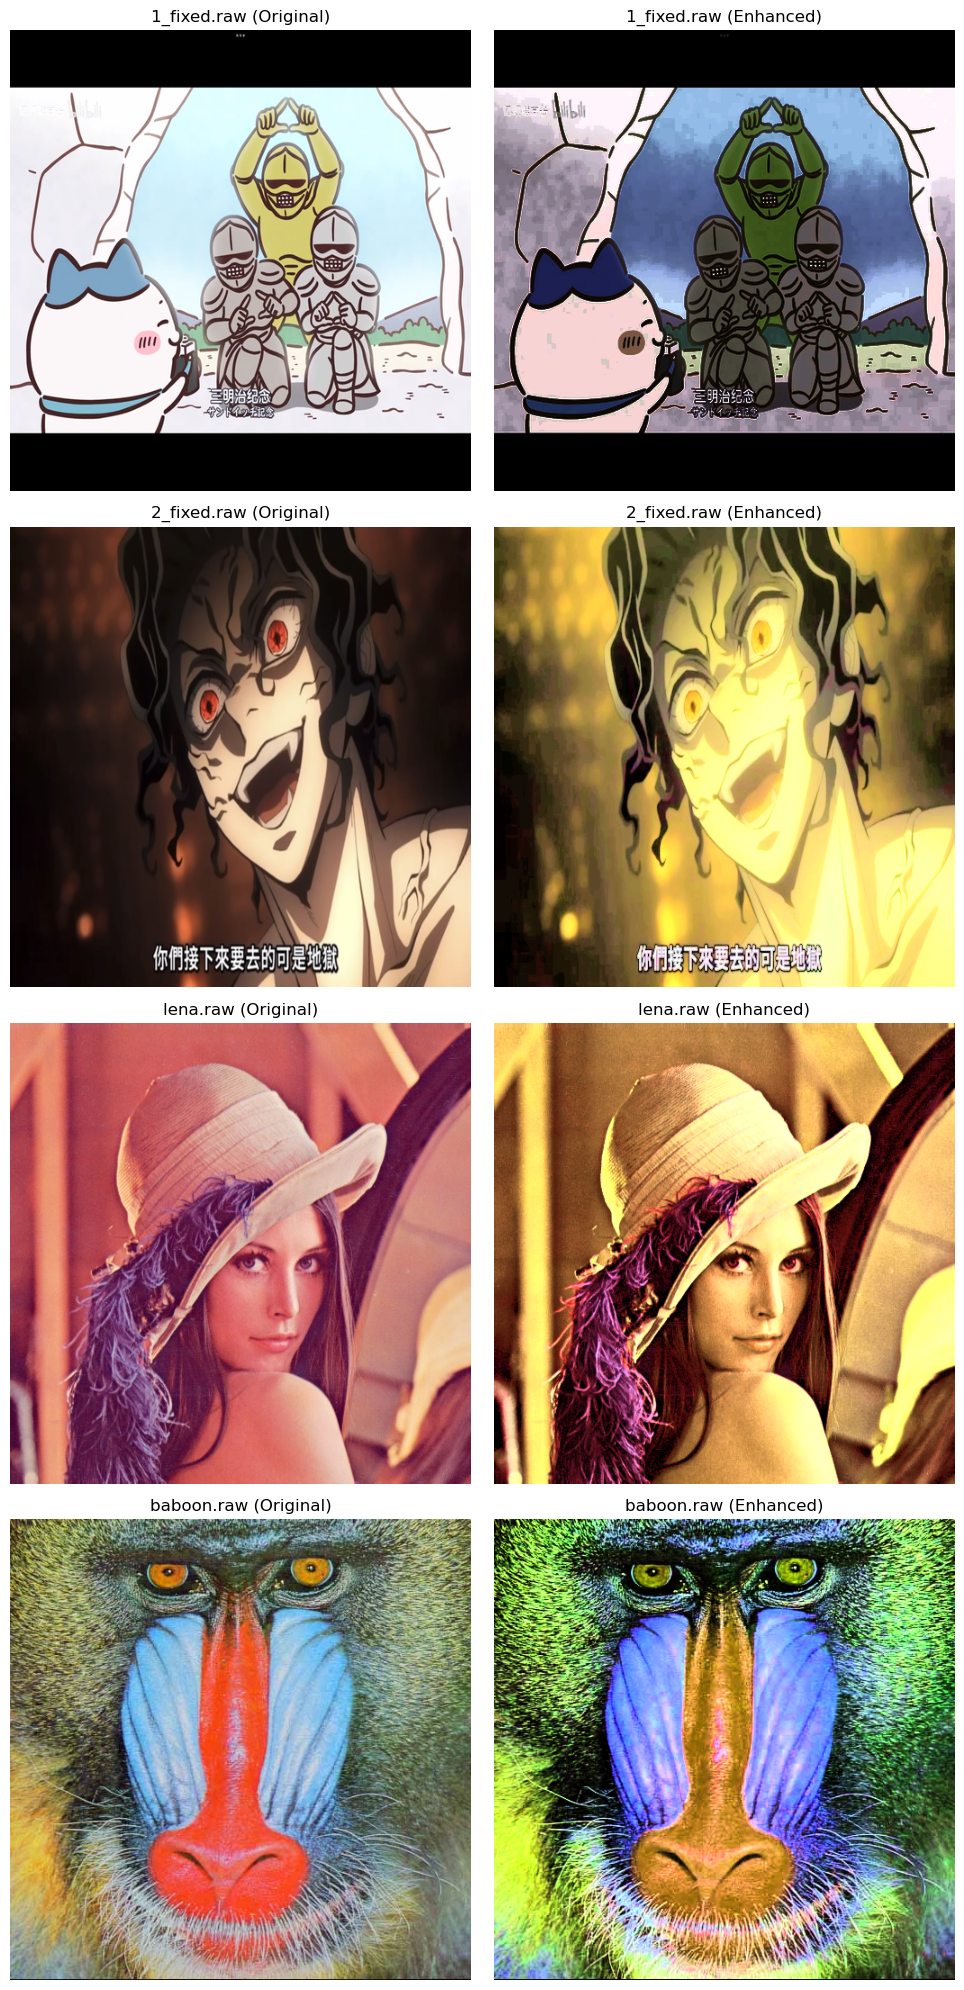

All files processed and saved.


In [5]:
def process_single_image(filename):
    """
    讀取單張影像 -> 處理 -> 回傳 (原始圖, 處理後圖)
    """
    print(f"Processing {filename}...")
    img = read_sequential_raw(filename)
    
    if img is None:
        return None, None

    # 1. RGB -> HSI
    H, S, I = rgb_to_hsi(img)

    # 2. Apply Enhancements
    # (A) Histogram Equalization on I
    I_new = histogram_equalization(I)
    
    # (B) Gamma Transformation on S (S^gamma)
    # gamma < 1 變亮/鮮豔, gamma > 1 變暗/平淡
    S_new = gamma_transformation(S, gamma=0.6) 
    
    # (C) Custom Hue Shift on H
    H_new = custom_hue_processing(H)

    # 3. HSI -> RGB
    img_out = hsi_to_rgb(H_new, S_new, I_new)

    # 4. Clipping & Converting to uint8
    img_out_clipped = np.clip(img_out, 0, 255).astype(np.uint8)
    
    # 5. Save output file
    name, ext = os.path.splitext(filename)
    output_filename = f"{name}_enhanced.raw"
    save_sequential_raw(img_out_clipped, output_filename)
    
    return img, img_out_clipped

def main():
    # 定義你的檔案列表
    file_list = ['1_fixed.raw', '2_fixed.raw', 'lena.raw', 'baboon.raw']
    
    # 準備繪圖 (4列 x 2行: 左邊原始, 右邊處理後)
    # 這裡假設所有圖都是 512x512
    num_files = len(file_list)
    fig, axes = plt.subplots(num_files, 2, figsize=(10, 5 * num_files))
    
    # 如果只有一張圖，axes 可能不是陣列，需做處理
    if num_files == 1:
        axes = np.array([axes])

    for idx, filename in enumerate(file_list):
        # 處理影像
        img_org, img_enh = process_single_image(filename)
        
        if img_org is not None:
            # 顯示原始圖
            axes[idx, 0].imshow(img_org)
            axes[idx, 0].set_title(f"{filename} (Original)")
            axes[idx, 0].axis('off')
            
            # 顯示處理後圖
            axes[idx, 1].imshow(img_enh)
            axes[idx, 1].set_title(f"{filename} (Enhanced)")
            axes[idx, 1].axis('off')
        else:
            # 讀檔失敗顯示空白
            axes[idx, 0].text(0.5, 0.5, 'File Not Found', ha='center')
            axes[idx, 1].text(0.5, 0.5, 'Error', ha='center')

    plt.tight_layout()
    plt.show()
    print("All files processed and saved.")

if __name__ == "__main__":
    main()

In [6]:

import matplotlib.pyplot as plt
import os

def generate_report_images(filename):
    print(f"Generating report images for {filename}...")
    img = read_sequential_raw(filename)
    if img is None: return

    # 1. 轉到 HSI
    H, S, I = rgb_to_hsi(img)

    # 2. 計算變化後的 H, S, I
    I_new = histogram_equalization(I)      # I channel 變化
    S_new = gamma_transformation(S, 0.6)   # S channel 變化
    H_new = custom_hue_processing(H)       # H channel 變化

    # 3. 產生四種不同的結果圖
    
    # (A) 只有 H 變 (S, I 用原本的) -> 觀察色相偏移
    img_H_only = hsi_to_rgb(H_new, S, I)
    
    # (B) 只有 S 變 (H, I 用原本的) -> 觀察飽和度變鮮豔
    img_S_only = hsi_to_rgb(H, S_new, I)
    
    # (C) 只有 I 變 (H, S 用原本的) -> 觀察對比度變清晰
    img_I_only = hsi_to_rgb(H, S, I_new)
    
    # (D) 全部一起變 (最終結果)
    img_All = hsi_to_rgb(H_new, S_new, I_new)

    # 4. 存成圖片 (PNG) 方便貼到 Word 報告
    # 這裡我們做一個 1x5 的大圖：原圖 | H變 | S變 | I變 | 全部變
    
    plt.figure(figsize=(20, 4))
    
    images = [img, img_H_only, img_S_only, img_I_only, img_All]
    titles = ['Original', 'H Channel Only (+30°)', 'S Channel Only (Gamma)', 'I Channel Only (HE)', 'All Combined']
    
    name = os.path.splitext(filename)[0]
    
    for i in range(5):
        plt.subplot(1, 5, i+1)
        # 轉成 uint8 並 clip 防止數值錯誤
        show_img = np.clip(images[i], 0, 255).astype(np.uint8)
        plt.imshow(show_img)
        plt.title(titles[i])
        plt.axis('off')
    
    # 儲存這張組合圖
    plt.tight_layout()
    plt.savefig(f'Report_{name}.png', dpi=150)
    plt.close()
    print(f"Saved Report_{name}.png")

def main():
    # 針對你要放在報告裡的圖執行
    # 建議跑這兩張最有代表性：
    files =  ['1_fixed.raw', '2_fixed.raw', 'lena.raw', 'baboon.raw']
    
    for f in files:
        generate_report_images(f)

if __name__ == "__main__":
    main()

Generating report images for 1_fixed.raw...
Saved Report_1_fixed.png
Generating report images for 2_fixed.raw...
Saved Report_2_fixed.png
Generating report images for lena.raw...
Saved Report_lena.png
Generating report images for baboon.raw...
Saved Report_baboon.png
